In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving ds_salaries.csv to ds_salaries (1).csv


In [9]:
df = pd.read_csv('ds_salaries.csv')
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (607, 12)

Column Names:
 ['Unnamed: 0', 'work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

First 5 rows:


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [12]:
df = df.drop(columns = ['Unnamed: 0'])

In [13]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [14]:
print("check for missing values")
print(df.isnull().sum())

check for missing values
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64


In [18]:
print("\nData Types:")
print(df.dtypes)

print("\nBasic Stats:")
df.describe()


Data Types:
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

Basic Stats:


,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


In [19]:
# Decode abbreviations into human readable labels
df['experience_level'] = df['experience_level'].map({
    'EN': 'Entry Level',
    'MI': 'Mid Level',
    'SE': 'Senior Level',
    'EX': 'Executive'
})

df['employment_type'] = df['employment_type'].map({
    'FT': 'Full Time',
    'PT': 'Part Time',
    'CT': 'Contract',
    'FL': 'Freelance'
})

df['company_size'] = df['company_size'].map({
    'S': 'Small',
    'M': 'Medium',
    'L': 'Large'
})

# Verify it worked
print("Experience Levels:", df['experience_level'].unique())
print("Employment Types:", df['employment_type'].unique())
print("Company Sizes:", df['company_size'].unique())

Experience Levels: ['Mid Level' 'Senior Level' 'Entry Level' 'Executive']
Employment Types: ['Full Time' 'Contract' 'Part Time' 'Freelance']
Company Sizes: ['Large' 'Small' 'Medium']


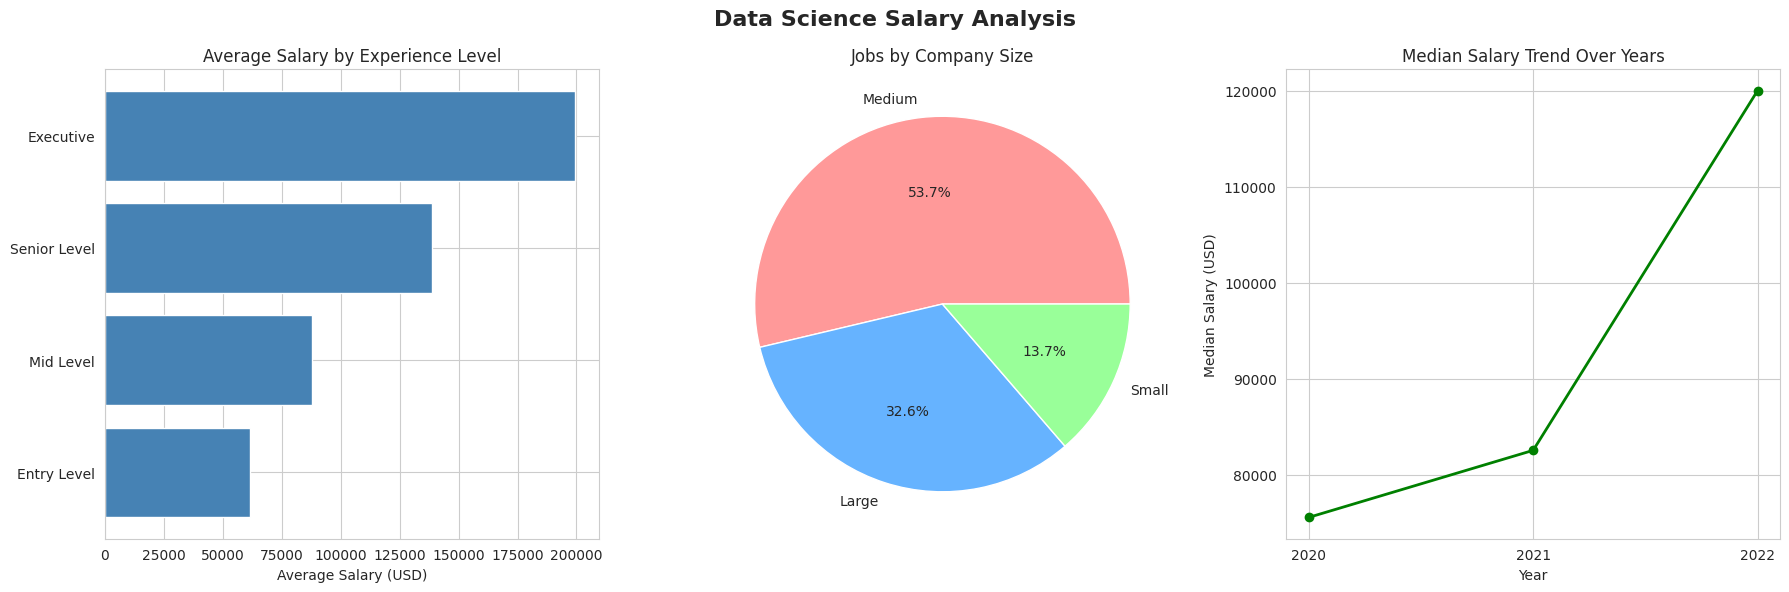

KEY INSIGHTS
1. Executive roles earn on average $199,392 USD
2. Medium companies dominate the market at 53.7% of all jobs
3. Median salary grew from $75,544 in 2020 to $120,000 in 2022
4. Total records analyzed: 607 job listings


In [21]:
# Fix the year axis and improve the trend chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Data Science Salary Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Average salary by experience level
exp_salary = df.groupby('experience_level')['salary_in_usd'].mean().sort_values()
axes[0].barh(exp_salary.index, exp_salary.values, color='steelblue')
axes[0].set_title('Average Salary by Experience Level')
axes[0].set_xlabel('Average Salary (USD)')

# Chart 2 - Jobs by company size
company_counts = df['company_size'].value_counts()
axes[1].pie(company_counts.values,
            labels=company_counts.index,
            autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff','#99ff99'])
axes[1].set_title('Jobs by Company Size')

# Chart 3 - Fixed year axis
year_salary = df.groupby('work_year')['salary_in_usd'].median()
axes[2].plot(year_salary.index, year_salary.values,
             marker='o', color='green', linewidth=2)
axes[2].set_title('Median Salary Trend Over Years')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Median Salary (USD)')
axes[2].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('salary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key insights
print("=" * 50)
print("KEY INSIGHTS")
print("=" * 50)
print(f"1. Executive roles earn on average "
      f"${df[df['experience_level']=='Executive']['salary_in_usd'].mean():,.0f} USD")
print(f"2. Medium companies dominate the market at "
      f"{(df['company_size']=='Medium').mean()*100:.1f}% of all jobs")
print(f"3. Median salary grew from "
      f"${df[df['work_year']==2020]['salary_in_usd'].median():,.0f} in 2020 to "
      f"${df[df['work_year']==2022]['salary_in_usd'].median():,.0f} in 2022")
print(f"4. Total records analyzed: {len(df)} job listings")
print("=" * 50)

In [22]:
# Final summary cell - add this as the last cell in your notebook
print("ANALYSIS SUMMARY")
print("=" * 50)
print("Dataset: Data Science Job Salaries 2020-2022")
print("Source: Kaggle")
print(f"Total Records: {len(df)}")
print("\nSteps Performed:")
print("1. Loaded and explored raw dataset")
print("2. Checked and confirmed zero missing values")
print("3. Decoded abbreviated labels to human readable format")
print("4. Generated 3 visualizations")
print("5. Extracted 4 key business insights")
print("\nTools Used: Python, Pandas, Matplotlib, Seaborn")

ANALYSIS SUMMARY
Dataset: Data Science Job Salaries 2020-2022
Source: Kaggle
Total Records: 607

Steps Performed:
1. Loaded and explored raw dataset
2. Checked and confirmed zero missing values
3. Decoded abbreviated labels to human readable format
4. Generated 3 visualizations
5. Extracted 4 key business insights

Tools Used: Python, Pandas, Matplotlib, Seaborn
